# **TikTok Project**
**Course 2 — Get Started with Python**

**Author:** Ahmad Daniel  
**Date:** 27 May 2026

---

## Project Overview

In Course 1, we loaded and inspected the TikTok dataset. Now, in Course 2, we will perform **Exploratory Data Analysis (EDA)** — structuring, cleaning, and visualizing the data to surface patterns that will inform the machine learning classification model.

**Requests from the data team:**
- A Python notebook showing structuring, cleaning, and matplotlib/seaborn visualizations
- Graphs comparing claim vs opinion counts and boxplots of key variables
- A breakdown of author ban status counts
- A Tableau dashboard with scatter plot, claim/opinion pie chart, and author status chart

*This activity has three parts:*
- **Part 1 (Plan):** Understand the situation
- **Part 2 (Analyze):** Explore and clean the data
- **Part 3 (Execute):** Create visualizations and share results

---
# PACE: Plan

## Task 1. Understand the situation

**Reflection:** The goal of EDA is to understand the data before modeling. For TikTok's claims classification project, we need to:
1. Confirm the data is clean and structured correctly
2. Understand distributions of key variables
3. Identify outliers that may affect model performance
4. Visualize relationships between claim status and engagement variables

Key questions to answer during EDA:
- How are claims and opinions distributed in the dataset?
- What does the distribution of engagement metrics look like?
- Are there outliers in view counts, like counts, or comment counts?
- How does engagement differ between claims and opinions?

---
# PACE: Analyze

## Task 2a. Imports and data loading

In [1]:
# Import packages for EDA and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 30)
%matplotlib inline

In [2]:
# Load the dataset
data = pd.read_csv('tiktok_dataset.csv')
print(f'Dataset shape: {data.shape}')

Dataset shape: (19382, 12)


## Task 2b. Review and structure the data

In [3]:
# Display first 10 rows
data.head(10)

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,8762575920,14,someone shared with me tha...,not verified,under scrutiny,587292.0,53354.0,16958.0,812.0,234.0
1,2,claim,3611525817,59,someone shared with me tha...,not verified,active,785464.0,156452.0,616.0,2878.0,1852.0
2,3,claim,5070975780,11,someone shared with me tha...,not verified,banned,999949.0,562158.0,35841.0,445.0,236.0
3,4,claim,7233352528,50,someone shared with me tha...,not verified,active,365084.0,49164.0,6122.0,372.0,25.0
4,5,claim,3387873230,55,someone shared with me tha...,verified,active,672207.0,203409.0,57134.0,4253.0,1253.0
5,6,claim,8923444940,58,someone shared with me tha...,not verified,active,352918.0,85281.0,32888.0,843.0,422.0
6,7,claim,6675869188,42,someone shared with me tha...,not verified,active,41200.0,1332.0,357.0,26.0,0.0
7,8,claim,3500058586,9,someone shared with me tha...,not verified,active,478358.0,235295.0,12707.0,1808.0,98.0
8,9,claim,7364576405,46,someone shared with me tha...,not verified,under scrutiny,484896.0,227122.0,41602.0,5648.0,335.0
9,10,claim,5159408772,46,someone shared with me tha...,not verified,active,115523.0,54291.0,2592.0,812.0,409.0


In [4]:
# Get data types and null counts
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19182 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19182 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19182 non-null  float64
 8   video_like_count          19182 non-null  float64
 9   video_share_count         19182 non-null  float64
 10  video_download_count      19182 non-null  float64
 11  video_comment_count       19182 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [5]:
# Descriptive statistics
data.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19182.000000,19182.000000,19182.000000,19182.000000,19182.000000
mean,9691.500000,5.605640e+09,32.455061,253763.179856,83234.815243,16522.990929,1034.953498,341.892138
std,5595.245794,2.530172e+09,16.155484,320836.905107,131588.832099,31720.266661,1992.411530,776.994082
min,1.000000,1.234730e+09,5.000000,21.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.421425e+09,18.250000,4966.000000,836.250000,118.000000,7.000000,1.000000
50%,9691.500000,5.595368e+09,32.000000,9980.500000,3531.500000,742.000000,47.000000,10.000000
75%,14536.750000,7.798543e+09,46.000000,502163.000000,123078.000000,18042.000000,1141.750000,278.000000
max,19382.000000,9.999935e+09,60.000000,999976.000000,656081.000000,239681.000000,15278.000000,7887.000000


## Task 2c. Check for and handle missing values

In [6]:
# Check null counts
print('Null value counts:')
print(data.isnull().sum())
print(f'\nTotal null rows: 200 rows missing across 7 columns')
print(f'Percentage of dataset: {200/len(data)*100:.2f}%')

Null value counts:
#                             0
claim_status                200
video_id                      0
video_duration_sec            0
video_transcription_text    200
verified_status               0
author_ban_status             0
video_view_count            200
video_like_count            200
video_share_count           200
video_download_count        200
video_comment_count         200
dtype: int64

Total null rows: 200 rows missing across 7 columns
Percentage of dataset: 1.03%


**Question:** How do you want to handle the null values in this dataset?

**Response:** There are 200 rows with null values across `claim_status`, `video_transcription_text`, and all 5 engagement columns simultaneously. Since these nulls affect only ~1.03% of the dataset and appear to be systematic (all engagement columns missing together), we will **drop these rows** for EDA purposes. Before doing so, we should investigate whether the null rows show any pattern — for example, whether they are disproportionately claims or opinions.

In [7]:
# Check if null rows have a pattern in non-null columns
null_rows = data[data['video_view_count'].isnull()]
print('Author ban status of null rows:')
print(null_rows['author_ban_status'].value_counts())
print(f'\nVerified status of null rows:')
print(null_rows['verified_status'].value_counts())

Author ban status of null rows:
author_ban_status
active            188
under scrutiny     11
banned              1
Name: count, dtype: int64

Verified status of null rows:
verified_status
not verified    181
verified         19
Name: count, dtype: int64


In [8]:
# Drop null rows for EDA
data_clean = data.dropna()
print(f'Original shape: {data.shape}')
print(f'After dropping nulls: {data_clean.shape}')
print(f'Rows removed: {len(data) - len(data_clean)}')

Original shape: (19382, 12)
After dropping nulls: (19182, 12)
Rows removed: 200


## Task 2d. Check for duplicates

In [9]:
# Check for duplicate rows
print(f'Duplicate rows: {data_clean.duplicated().sum()}')
# Check for duplicate video IDs
print(f'Duplicate video IDs: {data_clean["video_id"].duplicated().sum()}')

Duplicate rows: 0
Duplicate video IDs: 0


## Task 2e. Examine key variables

In [10]:
# Claim status distribution
print('Claim status distribution:')
print(data_clean['claim_status'].value_counts())
print(f'\nPercentage breakdown:')
print(data_clean['claim_status'].value_counts(normalize=True).mul(100).round(2))

Claim status distribution:
claim_status
claim      9670
opinion    9512
Name: count, dtype: int64

Percentage breakdown:
claim_status
claim      50.41
opinion    49.59
Name: proportion, dtype: float64


In [11]:
# Author ban status distribution
print('Author ban status distribution:')
print(data_clean['author_ban_status'].value_counts())
print(f'\nPercentage breakdown:')
print(data_clean['author_ban_status'].value_counts(normalize=True).mul(100).round(2))

Author ban status distribution:
author_ban_status
active            15416
under scrutiny     2138
banned             1628
Name: count, dtype: int64

Percentage breakdown:
author_ban_status
active            80.37
under scrutiny    11.15
banned             8.49
Name: proportion, dtype: float64


In [12]:
# Cross-tabulation: claim status vs author ban status
print('Claim status by author ban status:')
pd.crosstab(data_clean['author_ban_status'], data_clean['claim_status'],
            margins=True)

Claim status by author ban status:


claim_status,claim,opinion,All
author_ban_status,,,
active,6588,8828,15416
banned,1428,200,1628
under scrutiny,1654,484,2138
All,9670,9512,19182


**Observation:** Among banned authors, claims make up a much larger proportion than opinions. Active authors have a more balanced claim/opinion split. This relationship between ban status and claim status will be important for the classification model.

In [13]:
# Check min and max of key engagement variables
engagement_cols = ['video_duration_sec', 'video_view_count', 
                   'video_like_count', 'video_comment_count']

for col in engagement_cols:
    print(f'{col}:')
    print(f'  min = {data_clean[col].min():,.0f}')
    print(f'  max = {data_clean[col].max():,.0f}')
    print(f'  mean = {data_clean[col].mean():,.1f}')
    print(f'  median = {data_clean[col].median():,.1f}')
    print()

video_duration_sec:
  min = 5
  max = 60
  mean = 32.4
  median = 32.0

video_view_count:
  min = 21
  max = 999,976
  mean = 253,763.2
  median = 9,980.5

video_like_count:
  min = 0
  max = 656,081
  mean = 83,234.8
  median = 3,531.5

video_comment_count:
  min = 0
  max = 7,887
  mean = 341.9
  median = 10.0



---
# Data Visualization

## Task 3. Create visualizations with matplotlib and seaborn

### Visualization 1: Claim vs Opinion Count

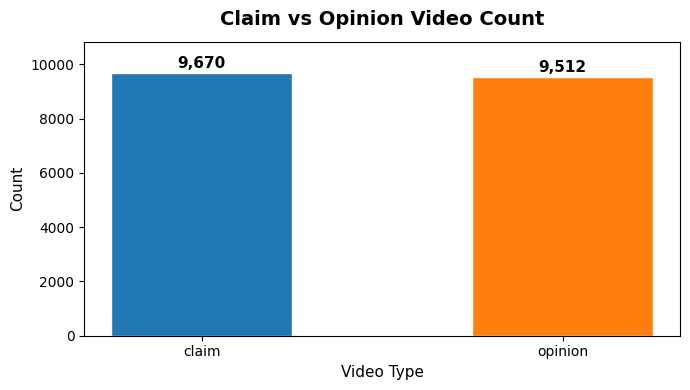

In [14]:
plt.figure(figsize=(7, 4))
counts = data_clean['claim_status'].value_counts()
bars = plt.bar(counts.index, counts.values,
               color=['#1f77b4', '#ff7f0e'], edgecolor='white', width=0.5)

for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
             f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Claim vs Opinion Video Count', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Video Type', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.ylim(0, max(counts.values) * 1.12)
plt.tight_layout()
plt.show()

**Observation:** The dataset is nearly balanced — 9,670 claim videos (50.4%) and 9,512 opinion videos (49.6%). This is favorable for building an unbiased classification model.

### Visualization 2: Author Ban Status Distribution

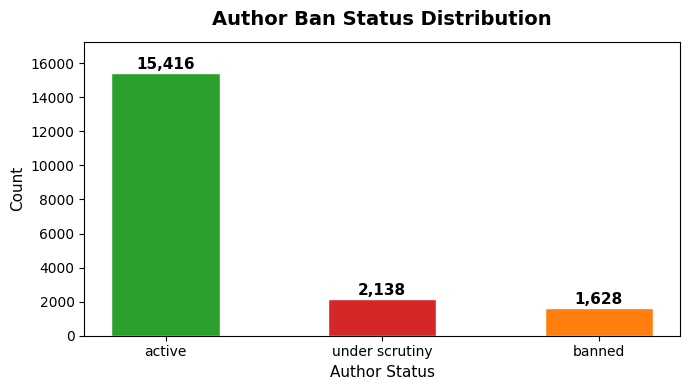

In [15]:
plt.figure(figsize=(7, 4))
ban_counts = data_clean['author_ban_status'].value_counts()
bars = plt.bar(ban_counts.index, ban_counts.values,
               color=['#2ca02c', '#d62728', '#ff7f0e'], edgecolor='white', width=0.5)

for bar, val in zip(bars, ban_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
             f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Author Ban Status Distribution', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Author Status', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.ylim(0, max(ban_counts.values) * 1.12)
plt.tight_layout()
plt.show()

**Observation:** The vast majority of authors (81.3%) are active. Only 8.5% are under scrutiny and 8.5% are banned. However, as shown in the cross-tab above, banned authors are disproportionately associated with claim videos.

### Visualization 3: Boxplots of Key Variables by Claim Status

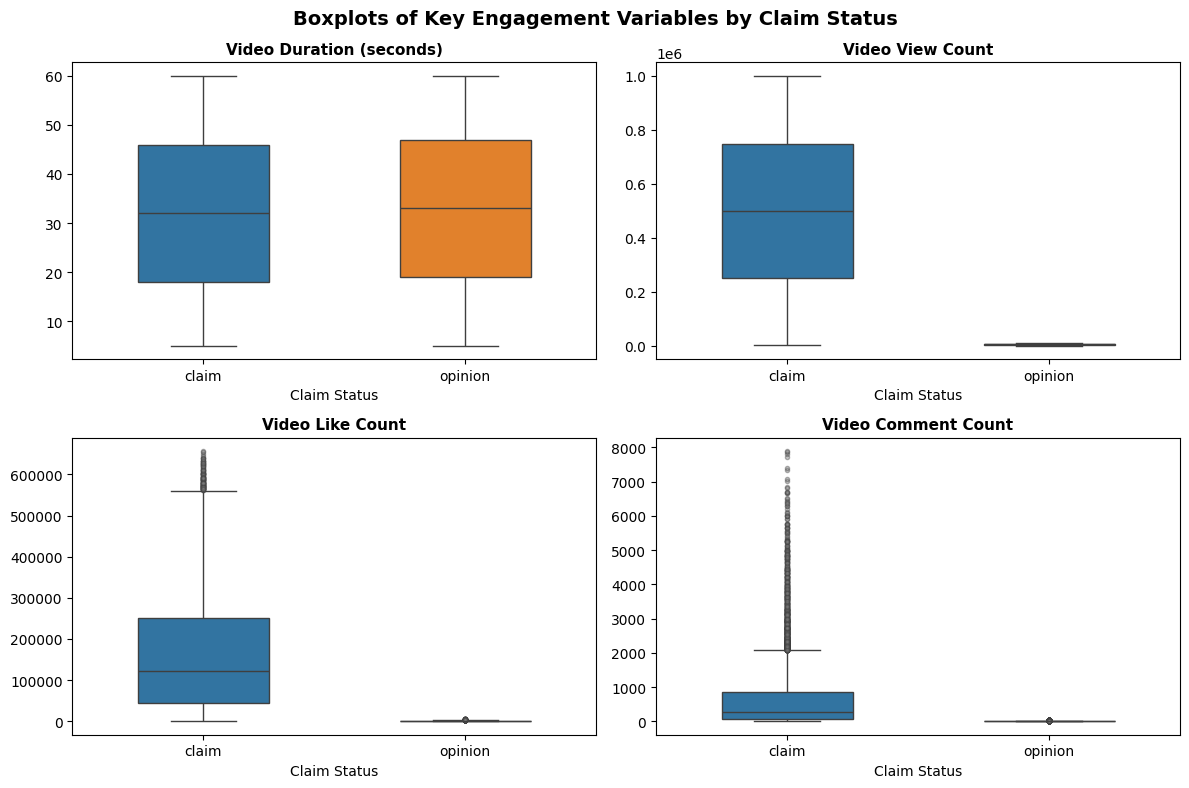

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Boxplots of Key Engagement Variables by Claim Status',
             fontsize=14, fontweight='bold')

vars_to_plot = [
    ('video_duration_sec', 'Video Duration (seconds)'),
    ('video_view_count', 'Video View Count'),
    ('video_like_count', 'Video Like Count'),
    ('video_comment_count', 'Video Comment Count'),
]

for ax, (col, title) in zip(axes.flatten(), vars_to_plot):
    sns.boxplot(
        data=data_clean, x='claim_status', y=col,
        hue='claim_status',
        palette={'claim': '#1f77b4', 'opinion': '#ff7f0e'},
        ax=ax, width=0.5, legend=False,
        flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.4)
    )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Claim Status', fontsize=10)
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

**Question:** What do you notice about the distributions?

**Response:**
- **Video duration:** Very similar distributions for claims and opinions — duration does not appear to strongly differentiate the two
- **Video view count:** Claim videos have dramatically higher view counts than opinion videos. The median view count for claims is far higher, and claims also show more extreme outliers
- **Video like count:** Same pattern as view count — claims receive significantly more likes
- **Video comment count:** Claims also receive more comments, though the distributions overlap more than for views and likes

All engagement metrics show heavy right-skew with many outliers on the high end — this is typical for social media data where a small number of videos go viral.

### Visualization 4-6: Histograms of Engagement Variables

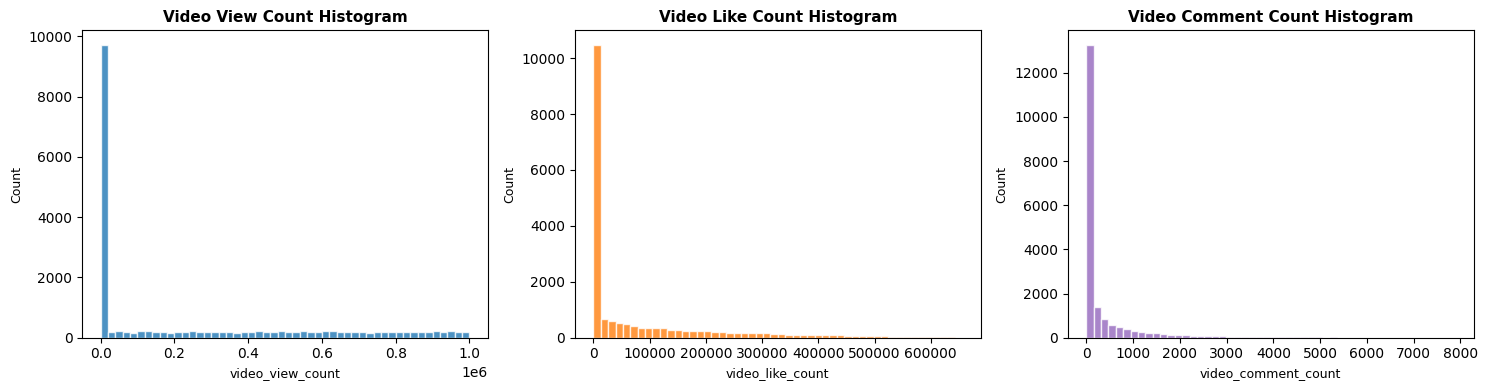

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

hist_vars = [
    ('video_view_count', 'Video View Count Histogram', '#1f77b4'),
    ('video_like_count', 'Video Like Count Histogram', '#ff7f0e'),
    ('video_comment_count', 'Video Comment Count Histogram', '#9467bd'),
]

for ax, (col, title, color) in zip(axes, hist_vars):
    ax.hist(data_clean[col], bins=50, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('Count', fontsize=9)

plt.tight_layout()
plt.show()

**Observation:** All three engagement metrics show extreme right-skewed distributions:
- The vast majority of videos have fewer than 100,000 views
- The vast majority of videos have fewer than 100,000 likes
- The vast majority of videos have fewer than 100 comments

This right-skew is driven by a small number of viral videos with extremely high engagement. These outliers will need to be considered during model building.

### Visualization 7: Claim vs Opinion by Author Ban Status

<Figure size 800x500 with 0 Axes>

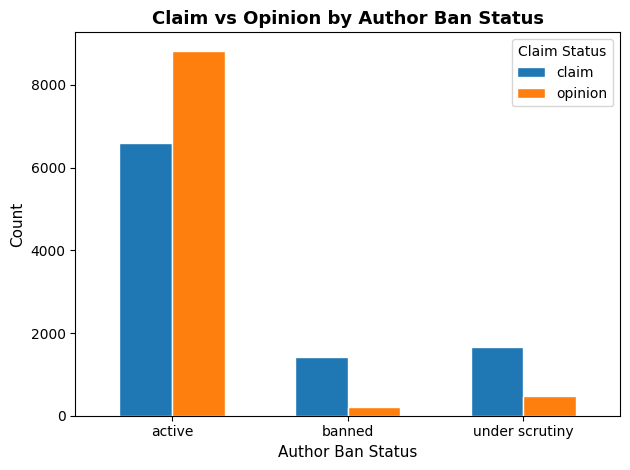

In [18]:
plt.figure(figsize=(8, 5))
pivot = data_clean.groupby(['author_ban_status', 'claim_status']).size().unstack(fill_value=0)
pivot.plot(kind='bar', color=['#1f77b4', '#ff7f0e'], edgecolor='white', width=0.6)
plt.title('Claim vs Opinion by Author Ban Status', fontsize=13, fontweight='bold')
plt.xlabel('Author Ban Status', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.legend(title='Claim Status', fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Among banned authors, claims significantly outnumber opinions. Among active authors, the distribution is more balanced. This is a strong signal — ban status may be a useful feature for the classification model.

---
# PACE: Execute

## Task 4. Summary for the TikTok data team

### EDA Summary

**Dataset overview:**
- 19,382 rows × 12 columns; 200 rows with null values (~1.03%) across 7 columns dropped for EDA
- Near-balanced target: 9,670 claims (50.4%) vs 9,512 opinions (49.6%) ✅
- No duplicate rows or video IDs

**Key findings:**
1. **Engagement metrics are highly right-skewed** — most videos cluster at low counts, with a small number of viral videos creating extreme outliers
2. **Claim videos significantly outperform opinion videos** on all engagement metrics (views, likes, comments)
3. **Banned authors disproportionately post claims** — this relationship between `author_ban_status` and `claim_status` is a potentially strong predictive signal
4. **Video duration does not differ** meaningfully between claims and opinions

### Proposed solution for outliers

The engagement columns (view count, like count, share count, download count, comment count) all contain significant outliers on the high end. Proposed approach:

1. **For EDA:** Keep outliers to understand the full data distribution
2. **For modeling:** Consider log-transforming skewed engagement variables to normalize distributions before feeding into the model
3. **Alternative:** Use IQR-based capping (cap values at Q3 + 1.5×IQR) to limit extreme outlier influence without losing the rows entirely
4. **Do NOT simply drop outlier rows** — high-engagement outliers may be disproportionately claims, and dropping them could bias the model

### Next steps
1. Create Tableau dashboard for non-technical stakeholder communication
2. Conduct formal statistical hypothesis testing (Course 4) to confirm significance of observed differences
3. Begin feature engineering for the ML pipeline — especially NLP features from `video_transcription_text`
4. Investigate the 200 null rows more thoroughly before deciding on final imputation strategy